In [13]:
!pip install ultralytics opencv-python-headless matplotlib seaborn pandas torch


In [14]:
import torch
import cv2
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from ultralytics import YOLO


In [15]:
# Check GPU availability
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

# Ensure Colab is using T4 GPU
gpu_info = !nvidia-smi --query-gpu=name --format=csv,noheader
if 'T4' not in gpu_info[0]:
    print("Warning: You are not using a T4 GPU. Consider switching runtime type.")

Using device: cuda


In [16]:
# Mount Google Drive (if dataset is stored there)
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
# Set dataset path (update this based on your dataset location)
dataset_path = '/content/drive/MyDrive/Colab Notebooks/Dataset'

In [27]:
# Define paths for train, validation, and test sets
image_dirs = {
    "train": os.path.join(dataset_path, 'images', 'train'),
    "valid": os.path.join(dataset_path, 'images', 'val'),
    "test": os.path.join(dataset_path, 'images', 'test')
}
label_dirs = {
    "train": os.path.join(dataset_path, 'labels', 'train'),
    "valid": os.path.join(dataset_path, 'labels', 'val'),
    "test": os.path.join(dataset_path, 'labels', 'test')
}


In [28]:
# Count images and annotations
for split in ["train", "valid", "test"]:
    num_images = len(os.listdir(image_dirs[split]))
    num_annotations = len(os.listdir(label_dirs[split]))
    print(f'{split.capitalize()} - Images: {num_images}, Annotations: {num_annotations}')


Train - Images: 1984, Annotations: 1984
Valid - Images: 189, Annotations: 189
Test - Images: 95, Annotations: 95


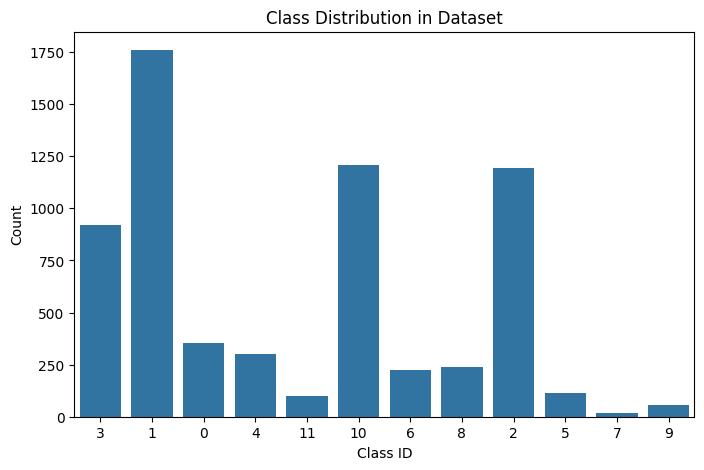

In [30]:
# Visualize class distribution
label_counts = {}
for split in label_dirs:
    for label_file in os.listdir(label_dirs[split]):
        if label_file.endswith('.txt'):
            with open(os.path.join(label_dirs[split], label_file), 'r') as f:
                for line in f:
                    class_id = line.split()[0]
                    label_counts[class_id] = label_counts.get(class_id, 0) + 1

# Convert to DataFrame for visualization
label_df = pd.DataFrame(list(label_counts.items()), columns=['Class', 'Count'])
plt.figure(figsize=(8, 5))
sns.barplot(x='Class', y='Count', data=label_df)
plt.xlabel('Class ID')
plt.ylabel('Count')
plt.title('Class Distribution in Dataset')
plt.show()



Visualizing random images with correct class names...


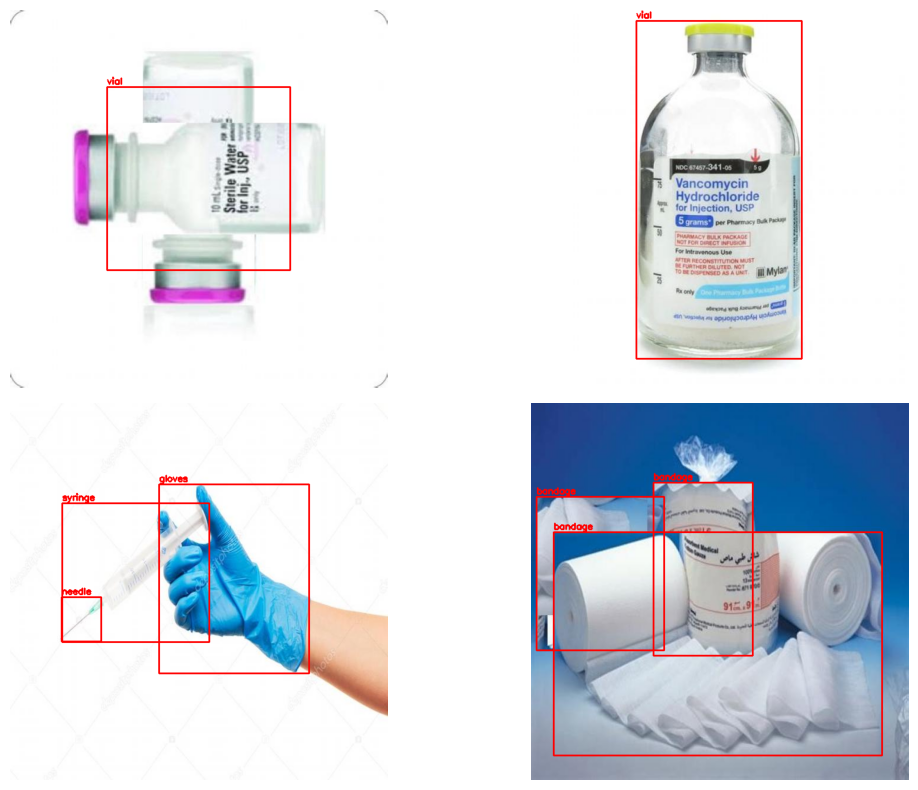

In [32]:
import yaml

# Load class names from YAML
yaml_path = os.path.join(dataset_path, "data.yaml")
with open(yaml_path, 'r') as f:
    data_yaml = yaml.safe_load(f)
class_names = data_yaml["names"]  # Class names list

# Function to visualize images with bounding boxes and actual class names
def plot_images_with_bboxes(image_dir, label_dir, num_samples=4):
    image_files = random.sample(os.listdir(image_dir), num_samples)
    plt.figure(figsize=(12, 8))

    for i, image_file in enumerate(image_files):
        img_path = os.path.join(image_dir, image_file)
        label_path = os.path.join(label_dir, image_file.replace('.jpg', '.txt'))

        if not os.path.exists(img_path):
            continue

        img = cv2.imread(img_path)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape

        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f:
                    values = line.split()
                    if len(values) < 5:
                        continue

                    class_id, x_center, y_center, bbox_width, bbox_height = map(float, values[:5])
                    class_id = int(class_id)
                    class_name = class_names[class_id] if class_id < len(class_names) else f"Class {class_id}"

                    # Convert YOLO bbox format to pixel coordinates
                    x1 = int((x_center - bbox_width / 2) * w)
                    y1 = int((y_center - bbox_height / 2) * h)
                    x2 = int((x_center + bbox_width / 2) * w)
                    y2 = int((y_center + bbox_height / 2) * h)

                    cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
                    cv2.putText(img, class_name, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

        plt.subplot(2, 2, i + 1)
        plt.imshow(img)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Visualize images with class names instead of IDs
print("Visualizing random images with correct class names...")
plot_images_with_bboxes(image_dirs["train"], label_dirs["train"])


In [33]:
# Load YOLOv8 model
model = YOLO('yolov8s.pt')  # Use 'yolov8n.pt' for a smaller model


100%|██████████| 21.5M/21.5M [00:00<00:00, 210MB/s]


In [34]:
model.train(
    data=f"{dataset_path}/data.yaml",  # Path to the dataset YAML file
    epochs=50,  # Adjust based on your needs
    batch=16,
    imgsz=640,
    device=device,
    workers=2,
    name='yolov8_medical_waste'
)

Ultralytics 8.3.93 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/drive/MyDrive/Colab Notebooks/Dataset/data.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=cuda, workers=2, project=None, name=yolov8_medical_waste, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False,

100%|██████████| 755k/755k [00:00<00:00, 26.8MB/s]


Overriding model.yaml nc=80 with nc=12

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  6                  -1  2    788480  ultralytics.nn.modules.block.C2f             [256, 256, 2, True]           
  7                  -1  1   1180672  ultralytic

100%|██████████| 5.35M/5.35M [00:00<00:00, 91.1MB/s]


AMP: checks passed ✅


...

                   all        189        519      0.765      0.591      0.615      0.452



50 epochs completed in 0.692 hours.
Optimizer stripped from runs/detect/yolov8_medical_waste/weights/last.pt, 22.5MB
Optimizer stripped from runs/detect/yolov8_medical_waste/weights/best.pt, 22.5MB

Validating runs/detect/yolov8_medical_waste/weights/best.pt...
Ultralytics 8.3.93 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,130,228 parameters, 0 gradients, 28.5 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:04<00:00,  1.47it/s]


                   all        189        519      0.855      0.549      0.625      0.455
                IVtube         23         26      0.795      0.654      0.729      0.453
               bandage         31        112      0.902      0.875      0.927      0.823
                cotton         27        117      0.741      0.632      0.671      0.431
                gloves         49         96      0.857      0.573      0.702      0.526
                  mask         23         30      0.915      0.717      0.829      0.558
           medical cap          7          9      0.842      0.889      0.951      0.725
                needle         10         10      0.641        0.3      0.476      0.338
              scissors          1          2          1          0          0          0
               syringe         19         19       0.84      0.684      0.847      0.522
             test tube          1          1          1          0          0          0
                  via

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7875933ae850>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,  